importar las librerias necesarias para el trabajo, destaca datasets que contiene dataset como CIFAR 10.

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
import random

El dataset CIFAR 10: El conjunto de datos CIFAR-10 es una colección de imágenes muy utilizada en aprendizaje automático y visión por computadora. Consta de 60.000 imágenes a color de 32x32, divididas en 10 clases distinta

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

Las imagenes se representan en matrices cubicas de pixeles, cada pixel tiene un valor entre 0 y 255, es por ello que la normalización en estos casos es mediante la división simple por 255.

In [ ]:
#

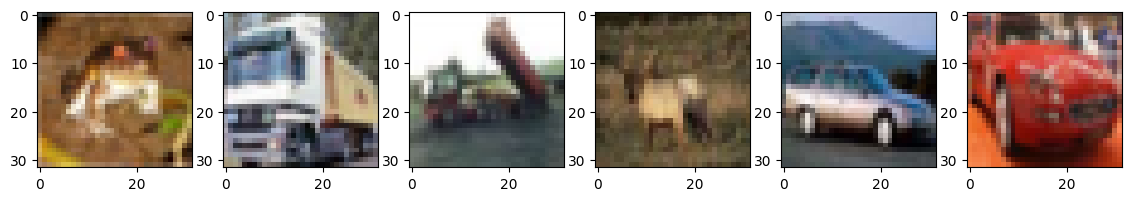

In [ ]:
plt.figure(figsize=(14,4))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(x_train[i])

Se definen las clase de CIFAR 10, un total de 10:
* Airplante
* Automobile
* Bird
* Cat
* Deer
* Dog
* Frog
* Horse
* Ship
* Truck

In [ ]:
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

Se define el modelo de capas convolucionales, pooling, flatten y dense:


Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)) :
 - 32 filtros/kernels que aprenderá esta capa
 - Cada filtro es una matriz de 3×3 que se deslizará sobre la imagen para extraer características.
- Activation='relu': Aplica max(0, x) a cada valor de salida:
- 32×32: Dimensiones de la imagen (alto × ancho) y 3 dimensiones solo en la primera capa.

MaxPooling2D((2, 2)):
- Divide el feature map en ventanas de 2×2 píxeles.
- Selecciona el valor máximo dentro de cada ventana 2×2 y descarta el resto.

Flatten: Aplanamiento de los mapas de caracteristicas ejem: 32 x 32 x3 -> un vector con 32 x 32 x3 datos

In [ ]:
model = models.Sequential([
layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D((2,2)),
layers.Conv2D(128,(3,3),activation='relu'),
layers.Flatten(),
layers.Dense(64,activation='relu'),
layers.Dense(10,activation='softmax')
])

Compilamos el modelo usando Categorical Crossentropy

In [ ]:
model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"]
)

Se realiza el entrenamiento

In [ ]:
history = model.fit(
    x_train,y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test,y_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4248 - loss: 1.8182 - val_accuracy: 0.4781 - val_loss: 1.4423
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5584 - loss: 1.2494 - val_accuracy: 0.5986 - val_loss: 1.1353
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6236 - loss: 1.0776 - val_accuracy: 0.6051 - val_loss: 1.1557
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6618 - loss: 0.9708 - val_accuracy: 0.6329 - val_loss: 1.0556
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6932 - loss: 0.8801 - val_accuracy: 0.6350 - val_loss: 1.0578
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7173 - loss: 0.8075 - val_accuracy: 0.6648 - val_loss: 1.0103
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7398 - loss: 0.7466 - val_accuracy: 0.6586 - val_loss: 1.0379
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7609 - loss: 0.6845 - val_accuracy: 0.

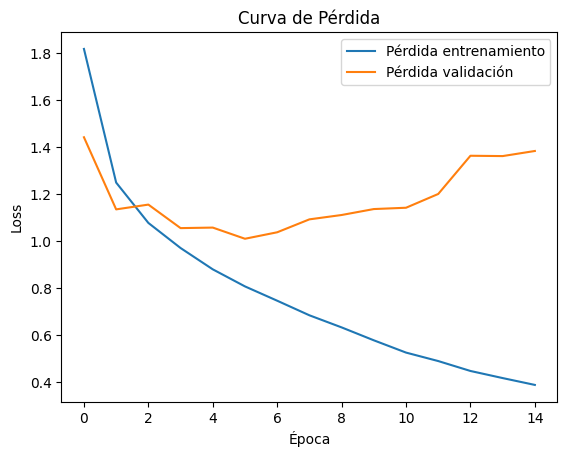

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

Se calcula la precisión como medida de perdida

In [ ]:
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f"precisión en el test, {test_acc:.2f}")

313/313 - 1s - 4ms/step - accuracy: 0.6617 - loss: 1.3838
precisión en el test, 0.66


In [ ]:
prediccion = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
y_pred = np.argmax(prediccion, axis=1)
y_true = y_test.flatten()

Se hace un muestreo aleatorio de elementos para ver la categoria con la imagen generada

/tmp/ipykernel_1099/830356201.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(y_test[idx])


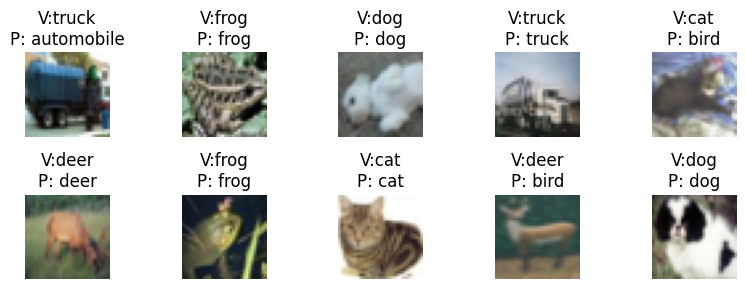

In [ ]:
num_imgs_show = 10
indices = random.sample(range(len(x_test)), num_imgs_show)

plt.figure(figsize=(8, 3))
for i, idx in enumerate(indices):
    img = x_test[idx]
    true_label = int(y_test[idx])
    pred_label = np.argmax(prediccion[idx])
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"V:{class_names[true_label]}\nP: {class_names[pred_label]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

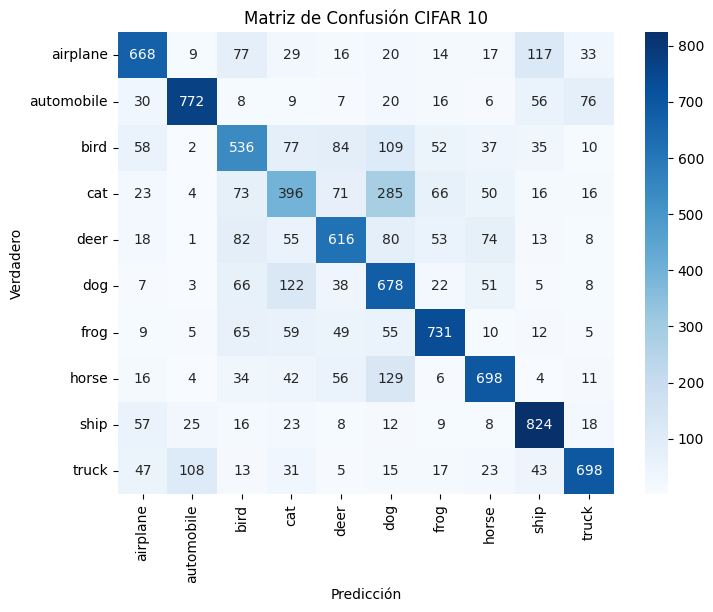

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión CIFAR 10')
plt.show()